# Chapter 02: One Prediction, Five Explanations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch02-map-of-the-territory.ipynb)

Companion notebook for Chapter 2 of *Hands-On Explainable AI*.

**What you'll build:** one sentiment prediction from a fine-tuned transformer, explained five different
ways: LIME, SHAP, Integrated Gradients, attention, and the model family's own natural-language
self-explanation. The five answers will *disagree*, and that disagreement is the reason this book
exists: you need a map of the method space, not a favorite hammer.

Runs on free-tier Colab (CPU is fine, ~3–5 minutes end to end).

This lab is part of *Hands-On Explainable AI: Interpreting, Evaluating, and Trusting Large Language Models* by [Hadi Mohammadi](https://mohammadi.cv). Code is MIT licensed; the repository and citation info live at [hands-on-xai-labs](https://github.com/mohammadi-hadi/hands-on-xai-labs) (DOI: [10.5281/zenodo.21804605](https://doi.org/10.5281/zenodo.21804605)).

In [1]:
%%capture
# Pinned installs (Colab only). Local envs come from the repo's pyproject.toml (`make setup-ml`).
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q transformers==4.57.* shap==0.49.* lime==0.2.* captum==0.9.*

In [2]:
import os
import random
import re

import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Smoke mode: CI sets BOOK_SMOKE=1 to shrink sampling budgets (results get noisier, runtime tiny)
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
DEVICE = "cpu"  # everything here is small enough that CPU keeps the lab reproducible anywhere
print(f"smoke={SMOKE}")

smoke=False


## The specimen

One model, one sentence. The model is a standard DistilBERT fine-tuned on SST-2 movie-review
sentiment. It is small, open, and downloaded by millions, which makes it a good shared reference point.
The sentence is deliberately ambivalent: a negative first half, a positive second half.

In [3]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, attn_implementation="eager"
).to(DEVICE).eval()
pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, top_k=None, device=-1)

SENTENCE = "The plot was dull, but the acting saved the film."

for entry in pipe(SENTENCE)[0]:
    print(f"{entry['label']:<9} {entry['score']:.3f}")

Device set to use cpu


POSITIVE  0.997
NEGATIVE  0.003


In [4]:
# Display vocabulary: the sentence's words and their character spans.
# Every method below reports scores on its OWN token granularity; we aggregate
# everything back onto these words so the five explanations are comparable.
WORDS = [(m.group(0), m.start(), m.end()) for m in re.finditer(r"[A-Za-z]+", SENTENCE)]
WORD_LABELS = [w for w, _, _ in WORDS]
print(WORD_LABELS)


def span_to_word(start: int, end: int) -> int | None:
    """Map a character span to the index of the display word it overlaps."""
    for i, (_, ws, we) in enumerate(WORDS):
        if start < we and end > ws:
            return i
    return None


def predict_proba(texts):
    """[P(neg), P(pos)] rows for a list of strings; the black-box interface."""
    probs = []
    for i in range(0, len(texts), 64):
        batch = tokenizer(list(texts[i : i + 64]), return_tensors="pt",
                          padding=True, truncation=True)
        with torch.no_grad():
            logits = model(**batch).logits
        probs.append(torch.softmax(logits, dim=-1).numpy())
    return np.vstack(probs)


POSITIVE = model.config.label2id["POSITIVE"]
print("P(positive) =", round(float(predict_proba([SENTENCE])[0, POSITIVE]), 3))

['The', 'plot', 'was', 'dull', 'but', 'the', 'acting', 'saved', 'the', 'film']
P(positive) = 0.997


## Method 1 (LIME): perturb the input, fit a local surrogate

LIME never looks inside the model. It deletes random subsets of words, watches the probability
move, and fits a small linear model to the results. `bow=False` keeps one weight per word
*occurrence* (the sentence has three "the"s, and they are allowed to matter differently).

In [5]:
from lime.lime_text import LimeTextExplainer

lime_explainer = LimeTextExplainer(class_names=["negative", "positive"], bow=False, random_state=SEED)
lime_exp = lime_explainer.explain_instance(
    SENTENCE,
    predict_proba,
    labels=(POSITIVE,),
    num_features=len(WORD_LABELS),
    num_samples=60 if SMOKE else 800,
)

lime_scores = np.zeros(len(WORD_LABELS))
indexed = lime_exp.domain_mapper.indexed_string
for feature_id, weight in lime_exp.as_map()[POSITIVE]:
    start = int(np.ravel(indexed.string_position(feature_id))[0])
    word = indexed.word(feature_id)
    idx = span_to_word(start, start + len(word))
    if idx is not None:
        lime_scores[idx] += weight

for w, s in zip(WORD_LABELS, lime_scores):
    print(f"{w:<8} {s:+.3f}")

The      -0.078
plot     -0.073
was      -0.033
dull     +0.085
but      +0.289
the      +0.025
acting   -0.033
saved    +0.366
the      +0.260
film     +0.277


## Method 2 (SHAP): the same perturbation idea, with game-theoretic bookkeeping

SHAP treats tokens as players in a cooperative game and distributes the prediction among them as
Shapley values. Same black-box access as LIME, different guarantees (and different answers).

In [6]:
import shap

shap_explainer = shap.Explainer(pipe, seed=SEED)
shap_exp = shap_explainer([SENTENCE], max_evals=50 if SMOKE else 400, silent=True)

pos_col = list(shap_exp.output_names).index("POSITIVE")
shap_tokens = shap_exp.data[0]
shap_vals = shap_exp.values[0][:, pos_col]

shap_scores = np.zeros(len(WORD_LABELS))
cursor = 0
lowered = SENTENCE.lower()
for token, value in zip(shap_tokens, shap_vals):
    text = token.strip().lower()
    if not text or not any(c.isalpha() for c in text):
        continue
    found = lowered.find(text, cursor)
    if found == -1:
        continue
    idx = span_to_word(found, found + len(text))
    if idx is not None:
        shap_scores[idx] += value
    cursor = found + len(text)

for w, s in zip(WORD_LABELS, shap_scores):
    print(f"{w:<8} {s:+.3f}")

The      -0.025
plot     -0.048
was      -0.014
dull     -0.080
but      +0.083
the      +0.083
acting   -0.037
saved    +0.283
the      +0.322
film     +0.064


## Method 3 (Integrated Gradients): follow the gradients instead

One rung up the access ladder: IG needs the model's gradients. It walks from an information-free
baseline (all `[PAD]`) to the real input and integrates each token embedding's gradient along the
path. Subword scores are summed back onto words. Remember this move; it hides bugs (Chapter 4).

In [7]:
from captum.attr import LayerIntegratedGradients

encoding = tokenizer(SENTENCE, return_tensors="pt", return_offsets_mapping=True)
offsets = encoding.pop("offset_mapping")[0].tolist()
input_ids, attention_mask = encoding["input_ids"], encoding["attention_mask"]

baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)
baseline_ids[0, 0] = tokenizer.cls_token_id
baseline_ids[0, -1] = tokenizer.sep_token_id


def forward_positive(ids, mask):
    return torch.softmax(model(input_ids=ids, attention_mask=mask).logits, dim=-1)[:, POSITIVE]


lig = LayerIntegratedGradients(forward_positive, model.distilbert.embeddings)
attributions = lig.attribute(
    inputs=input_ids,
    baselines=baseline_ids,
    additional_forward_args=(attention_mask,),
    n_steps=12 if SMOKE else 50,
)
token_attr = attributions.sum(dim=-1)[0].detach().numpy()

ig_scores = np.zeros(len(WORD_LABELS))
for (start, end), value in zip(offsets, token_attr):
    if end == 0:  # special tokens
        continue
    idx = span_to_word(start, end)
    if idx is not None:
        ig_scores[idx] += value

for w, s in zip(WORD_LABELS, ig_scores):
    print(f"{w:<8} {s:+.3f}")

The      -0.006
plot     -0.031
was      -0.035
dull     +0.024
but      +0.304
the      +0.105
acting   +0.006
saved    -0.004
the      +0.236
film     +0.075


## Method 4 (Attention): read what the model looked at

No perturbation, no gradients: just the attention weights the forward pass produces anyway.
We average the final layer's heads and read the `[CLS]` row: how much each token fed the
classification summary. Note what's missing: attention has **no sign**. It cannot say a word
argued *against* the prediction, only that it was looked at (Chapter 5 is the full trial).

In [8]:
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)

cls_attention = outputs.attentions[-1][0].mean(dim=0)[0].numpy()  # last layer, mean heads, CLS row

attn_scores = np.zeros(len(WORD_LABELS))
for (start, end), value in zip(offsets, cls_attention):
    if end == 0:
        continue
    idx = span_to_word(start, end)
    if idx is not None:
        attn_scores[idx] += value

for w, s in zip(WORD_LABELS, attn_scores):
    print(f"{w:<8} {s:.3f}")

The      0.033
plot     0.009
was      0.064
dull     0.015
but      0.046
the      0.058
acting   0.066
saved    0.430
the      0.099
film     0.041


## Method 5: ask a model to explain

The zero-effort method everyone uses first: have an instruction-tuned model classify the sentence
and explain itself in prose. Fluent, friendly, and produced by the very kind of system we're
trying to audit. Whether such rationales track the real computation is Chapter 9's question.

In [9]:
SELF_EXPLANATION_FALLBACK = (
    'Positive. Reasoning: The review states that while the plot was "dull," the acting '
    'contributed to making up for it and ultimately saving the film. This indicates that '
    'despite the lackluster plot, the performances were sufficient to balance out the '
    'otherwise unengaging elements of the movie. Therefore, the overall sentiment is positive.'
)  # verbatim output of a full run (line breaks collapsed), kept for smoke mode

if SMOKE:
    self_explanation = SELF_EXPLANATION_FALLBACK
else:
    from transformers import pipeline as hf_pipeline

    generator = hf_pipeline("text-generation", model="Qwen/Qwen2.5-0.5B-Instruct", device=-1)
    messages = [{
        "role": "user",
        "content": (
            f"Classify the sentiment of this movie review sentence as positive or negative, "
            f"then explain your reasoning in two short sentences.\n\nSentence: {SENTENCE!r}"
        ),
    }]
    result = generator(messages, max_new_tokens=90, do_sample=False)
    self_explanation = result[0]["generated_text"][-1]["content"].strip()

print(self_explanation)

Device set to use cpu


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Positive.
Reasoning:
The review states that while the plot was "dull," the acting contributed to making up for it and ultimately saving the film. This indicates that despite the lackluster plot, the performances were sufficient to balance out the otherwise unengaging elements of the movie. Therefore, the overall sentiment is positive.


## Five answers, side by side

Signed methods (LIME, SHAP, IG) are each scaled by their own largest magnitude; attention is scaled
to its maximum. Teal pushes toward *positive*, rose toward *negative*, attention can only be
"bright". Look at `dull`, `but`, and `saved`: the methods do not tell one story.

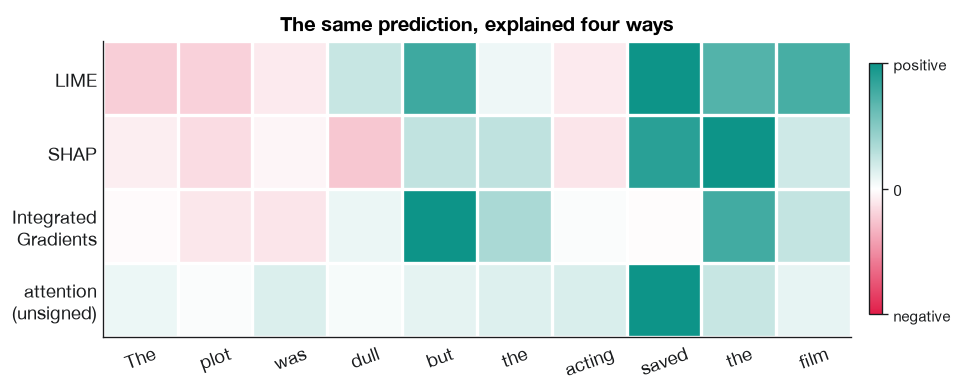

Method 5, the model's own story:

Positive.
Reasoning:
The review states that while the plot was "dull," the acting contributed to making up for it and ultimately saving the film. This indicates that despite the lackluster plot, the performances were sufficient to balance out the otherwise unengaging elements of the movie. Therefore, the overall sentiment is positive.


In [10]:
#| label: fig-five-explanations
#| fig-cap: "One prediction (P(positive) = 0.997), four attribution maps that disagree: attention cannot even express opposition. The model's prose rationale (printed below) is a fifth, unverified story."
#| fig-alt: "Heatmap with four attribution rows (LIME, SHAP, Integrated Gradients, unsigned attention) over the tokens of one review: the methods highlight different words and disagree in sign."
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

try:  # book house style when run inside the repo; Colab falls back to defaults
    plt.style.use("../styles/book.mplstyle")
except OSError:
    pass

def scaled(v):
    m = np.abs(v).max()
    return v / m if m else v

rows = np.vstack([
    scaled(lime_scores),
    scaled(shap_scores),
    scaled(ig_scores),
    attn_scores / attn_scores.max(),
])
methods = ["LIME", "SHAP", "Integrated\nGradients", "attention\n(unsigned)"]

book_diverging = LinearSegmentedColormap.from_list("book", ["#E11D48", "#FFFFFF", "#0D9488"])

fig, ax = plt.subplots(figsize=(8.6, 3.4))
im = ax.imshow(rows, cmap=book_diverging, norm=Normalize(-1, 1), aspect="auto")
ax.set_xticks(range(len(WORD_LABELS)), WORD_LABELS, rotation=20)
ax.set_yticks(range(len(methods)), methods)
ax.set_xticks(np.arange(-0.5, len(WORD_LABELS)), minor=True)
ax.set_yticks(np.arange(-0.5, len(methods)), minor=True)
ax.grid(which="minor", color="white", linewidth=2)
ax.grid(which="major", visible=False)
ax.tick_params(which="both", length=0)
cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02, ticks=[-1, 0, 1])
cbar.ax.set_yticklabels(["negative", "0", "positive"], fontsize=9)
ax.set_title("The same prediction, explained four ways")
plt.tight_layout()
plt.show()

print("Method 5, the model's own story:\n")
print(self_explanation)

## What just happened

Four quantitative methods produced four different maps of the *same* prediction, and the prose
rationale is a fifth account no map can confirm. None of them is "the" explanation; each answers a
slightly different question, under different access assumptions, with different failure modes.
Chapter 2 builds the taxonomy that turns this mess into a decision: four questions (**scope,
mechanism, access, output form**) and one selection tree.

## Now try it on your own data

Swap `SENTENCE` for a sentence from your domain (a support ticket, a review, a moderation case),
ideally one with a "but" in the middle. Re-run all five methods. Which words do the methods agree
on? Where they disagree, form a hypothesis about *why* (perturbation OOD-ness? gradient
saturation? attention's missing sign?). You'll test hypotheses like these in Chapter 8.